# `partition` module demo

Uses the DBpedia-14 dataset (14 categories, ~67 MB). 
The pipeline: vectorise → topic model → cluster → split → visualise.

In [1]:
import tempfile, os
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

from corpus_helpers import partition

/Users/rastislavhronsky/Research/corpus-helpers/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load dataset

In [2]:
!pip install datasets

In [3]:
from datasets import load_dataset

# ~67 MB, 14 categories (Company, Athlete, Film, Plant, …)
ds = load_dataset('fancyzhx/dbpedia_14', split='train')
label_names = ds.features['label'].names

# # ~29 MB, 4 categories (World, Sports, Business, Tech)
# ds = load_dataset('ag_news', split='train')
# label_names = ds.features['label'].names

docs = ds['content']
true_labels = [label_names[i] for i in ds['label']]
file_sizes = [len(d.encode()) for d in docs]

print(f'{len(docs)} documents, {len(set(true_labels))} categories')
print('categories:', label_names)

560000 documents, 14 categories
categories: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']


## 2. Vectorise and fit topic model

In [4]:
vectorizer = CountVectorizer(min_df=10, max_df=0.8, max_features=10000)
docs_vect = vectorizer.fit_transform(docs)

model = partition.fit_topic_model(
    docs_vect,
    LatentDirichletAllocation,
    n_components=14,
    random_state=0,
    max_iter=20,
    n_jobs=-1,
)
print('topics shape:', model.components_.shape)

topics shape: (14, 10000)


## 3. Plot top words per topic

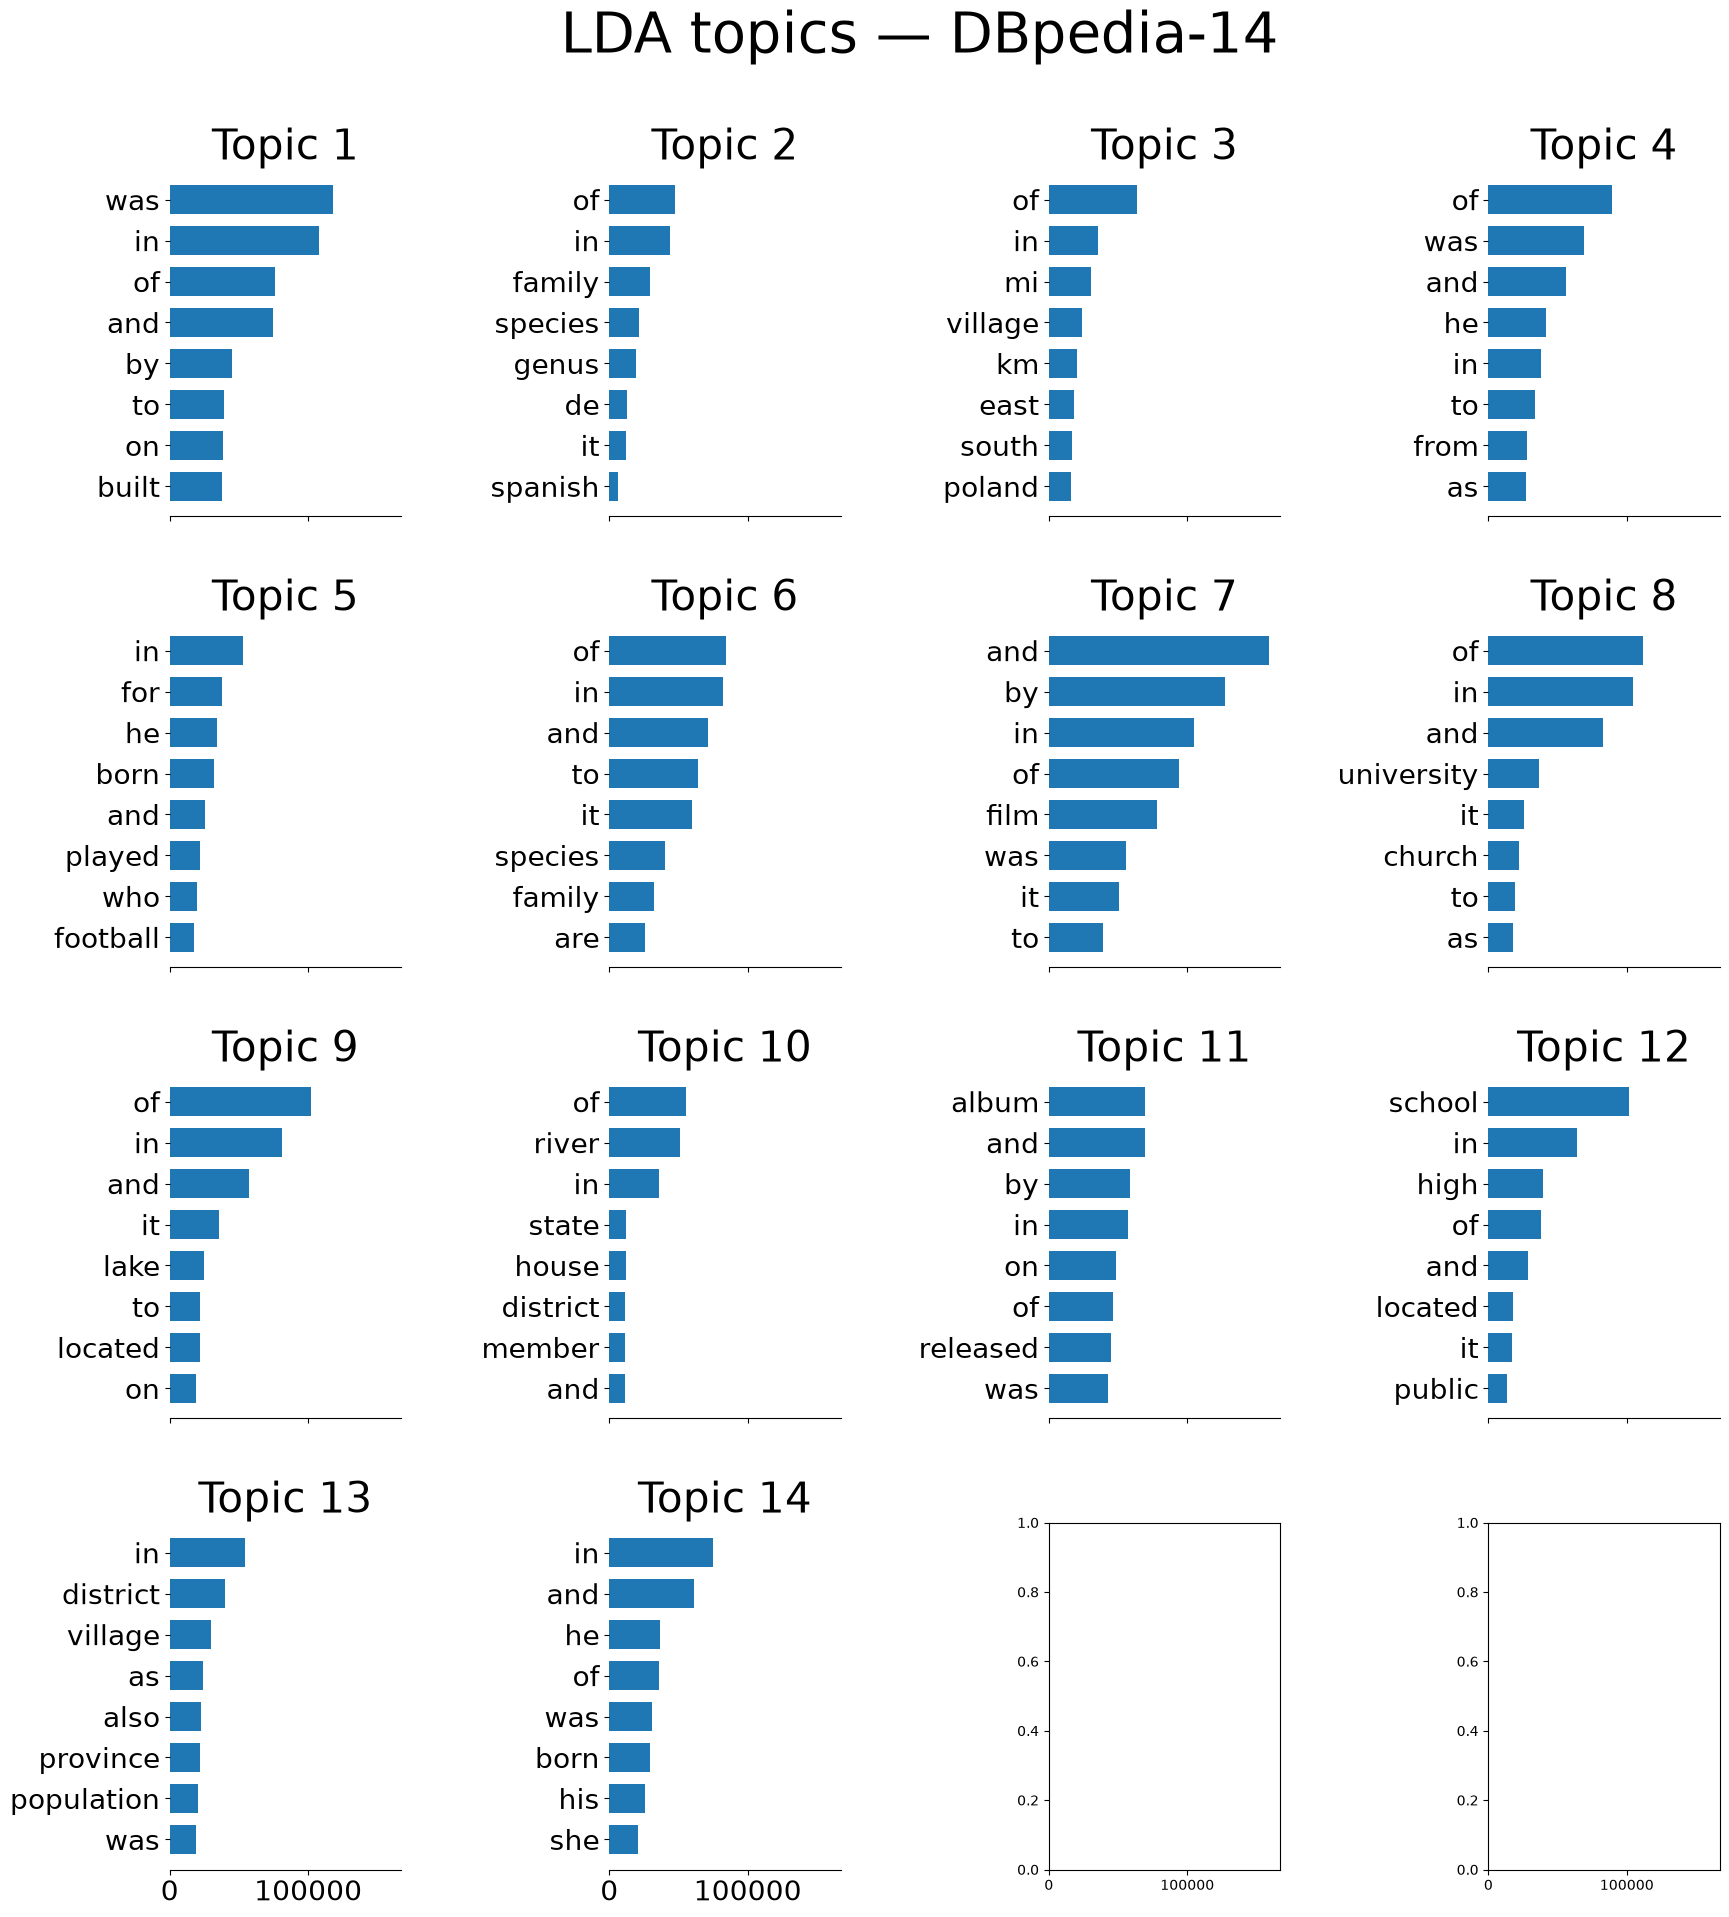

In [7]:
fig, axes = partition.plot_top_words(
    model,
    feature_names=vectorizer.get_feature_names_out(),
    n_top_words=8,
    title='LDA topics — DBpedia-14',
)
plt.show()

## 4. Save and reload topic model

In [5]:
partition.save_topic_model(model, vectorizer, 'test_topic_model')
model2, vec2 = partition.load_topic_model('test_topic_model')

print('save/load OK — components match:', np.allclose(model.components_, model2.components_))

save/load OK — components match: True


## 5. Project to topic space and cluster

In [6]:
docs_latent = model.transform(docs_vect)   # (n_docs, n_topics)

assign = partition.partition(docs_latent, n_clusters=14, seed=0)
print('cluster counts:', dict(zip(*np.unique(assign, return_counts=True))))

cluster counts: {np.int32(0): np.int64(43905), np.int32(1): np.int64(27790), np.int32(2): np.int64(92019), np.int32(3): np.int64(58497), np.int32(4): np.int64(51683), np.int32(5): np.int64(47135), np.int32(6): np.int64(20411), np.int32(7): np.int64(14337), np.int32(8): np.int64(37506), np.int32(9): np.int64(21606), np.int32(10): np.int64(35808), np.int32(11): np.int64(52163), np.int32(12): np.int64(25157), np.int32(13): np.int64(31983)}


## 6. Region sizes and iterative splitting

In [8]:
region_sizes = partition.get_region_sizes(assign, file_sizes)
print('region sizes (MB):', {k: f'{v:.1f}' for k, v in region_sizes.items()})

assign2 = partition.split_largest_region(assign, docs_latent, region_sizes, seed=0)
region_sizes2 = partition.get_region_sizes(assign2, file_sizes)
print(f'after split: {len(region_sizes)} → {len(region_sizes2)} regions')
print('new region sizes (MB):', {k: f'{v:.1f}' for k, v in region_sizes2.items()})

region sizes (MB): {0: '13.8', 1: '3.2', 2: '27.4', 3: '19.2', 4: '14.6', 5: '15.7', 6: '3.4', 7: '4.0', 8: '10.9', 9: '4.7', 10: '11.1', 11: '14.8', 12: '7.7', 13: '8.4'}
after split: 14 → 15 regions
new region sizes (MB): {0: '13.8', 1: '3.2', 2: '12.5', 3: '19.2', 4: '14.6', 5: '15.7', 6: '3.4', 7: '4.0', 8: '10.9', 9: '4.7', 10: '11.1', 11: '14.8', 12: '7.7', 13: '8.4', 14: '14.9'}


Text(0.5, 1.0, 'region sizes after the split:')

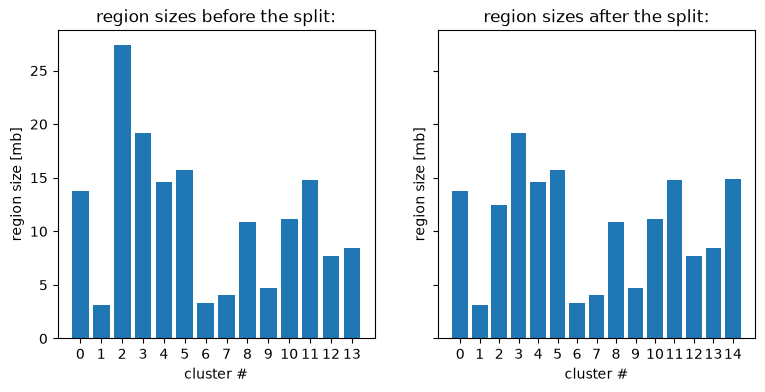

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9,4), sharey=True)

ax1.bar(region_sizes.keys(), region_sizes.values())
ax1.set_xticks(list(region_sizes.keys()))
ax1.set_xlabel('cluster #')
ax1.set_ylabel('region size [mb]')
ax1.set_title('region sizes before the split:')
ax2.bar(region_sizes2.keys(), region_sizes2.values())
ax2.set_xticks(list(region_sizes2.keys()))
ax2.set_xlabel('cluster #')
ax2.set_ylabel('region size [mb]')
ax2.set_title('region sizes after the split:')

## 7. t-SNE visualisation

In [20]:
rng = slice(0, None, 20)

In [21]:
coords = partition.fit_tsne(docs_latent[rng], n_points=len(docs_latent[rng]), seed=0)

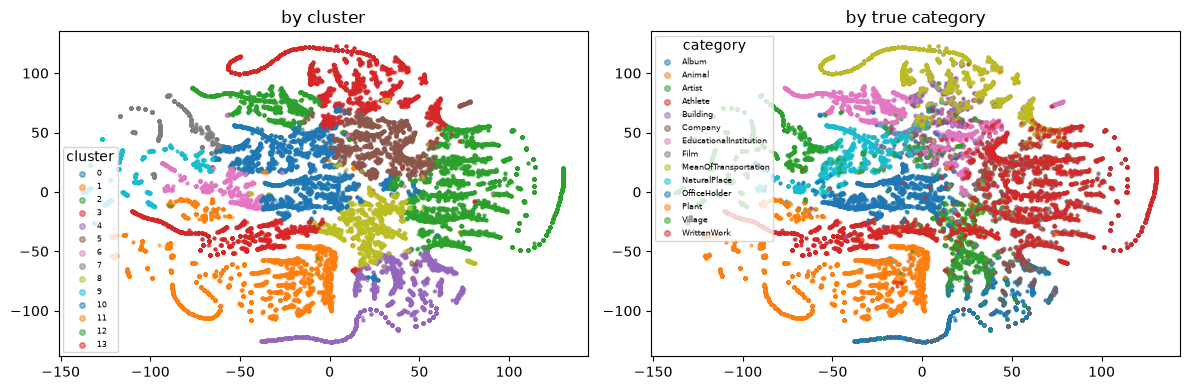

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))

partition.plot_tsne(coords, color_by=assign[rng], ax=ax1, s=4, alpha=0.5)
ax1.set_title('by cluster')
ax1.legend(title='cluster', fontsize=6, markerscale=2)

partition.plot_tsne(coords, color_by=true_labels[rng], ax=ax2, s=4, alpha=0.5)
ax2.set_title('by true category')
ax2.legend(title='category', fontsize=6, markerscale=2)

plt.tight_layout()
plt.show()

## 8. Most / least similar region subsets

In [ ]:
lo, hi = partition.make_subsets(assign2, docs_latent, subset_size=3)
print('most similar regions (lowest cosine distance):', lo)
print('most dissimilar regions (highest cosine distance):', hi)